In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings

In [2]:
df=pd.read_csv('../data/bank_customer_data.csv')
print(f" the shape of the dataset is {df.shape}")

 the shape of the dataset is (50000, 21)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       50000 non-null  str    
 1   age               50000 non-null  int64  
 2   gender            50000 non-null  str    
 3   marital_status    50000 non-null  str    
 4   education         50000 non-null  str    
 5   employment_type   50000 non-null  str    
 6   years_employed    50000 non-null  int64  
 7   annual_income     50000 non-null  int64  
 8   monthly_expenses  50000 non-null  int64  
 9   num_dependents    50000 non-null  int64  
 10  credit_score      50000 non-null  int64  
 11  existing_loans    50000 non-null  int64  
 12  missed_payments   50000 non-null  int64  
 13  savings_balance   50000 non-null  int64  
 14  investment_flag   50000 non-null  int64  
 15  loan_amount       50000 non-null  float64
 16  loan_tenure       50000 non-null  int64  
 17  inte

In [4]:
if df.isna().sum().sum()>0:
    print(" null exists")
else:
    print(" no null ")

 no null 


In [5]:
if df.duplicated().sum().sum()>0:
    print(" duplicates exist")
else:
    print(" unique data")

 unique data


In [6]:
df.head()

,customer_id,age,gender,marital_status,education,employment_type,years_employed,annual_income,monthly_expenses,num_dependents,...,existing_loans,missed_payments,savings_balance,investment_flag,loan_amount,loan_tenure,interest_rate,default,churn,credit_risk
0,CUST00001,56,Female,Married,Graduate,Salaried,33,627221,27346,0,...,1,1,292746,1,708007.0,21,18.45,0,0,Medium
1,CUST00002,69,Male,Single,Graduate,Salaried,40,668372,34942,2,...,2,0,137967,0,788237.0,21,15.79,0,0,Medium
2,CUST00003,46,Male,Single,High School,Self-Employed,26,554249,26827,3,...,1,1,60548,0,1060949.0,29,22.06,1,1,High
3,CUST00004,32,Female,Single,Graduate,Self-Employed,7,593807,34816,0,...,5,1,289507,0,1103022.0,4,20.94,0,1,Medium
4,CUST00005,60,Male,Married,High School,Salaried,31,396889,13767,5,...,0,0,155872,1,938617.0,7,19.68,0,0,Medium


In [7]:
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True))

churn
0    36739
1    13261
Name: count, dtype: int64
churn
0    0.73478
1    0.26522
Name: proportion, dtype: float64


<Axes: >

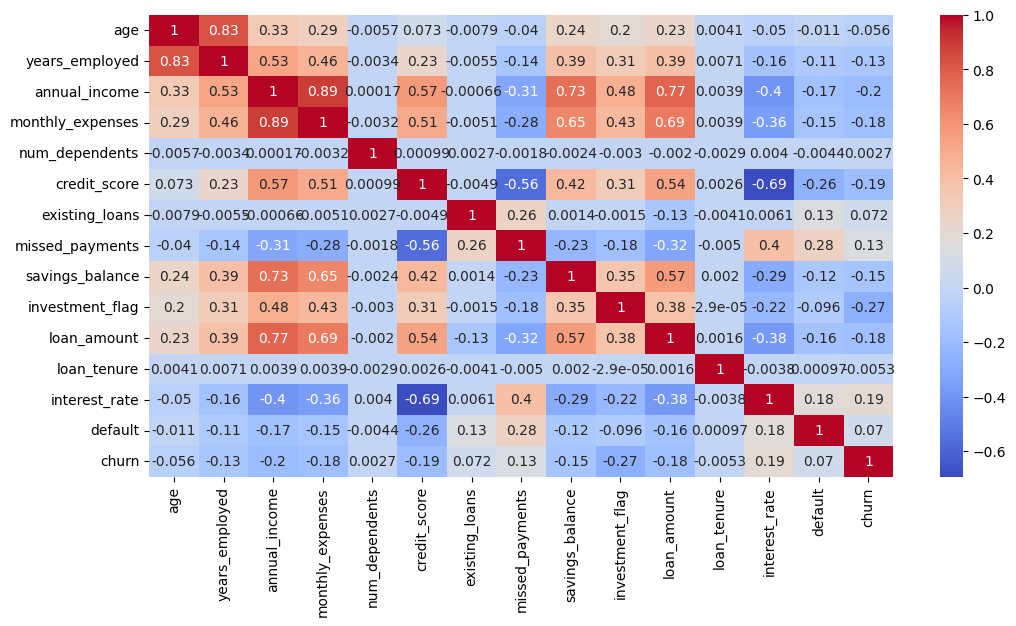

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

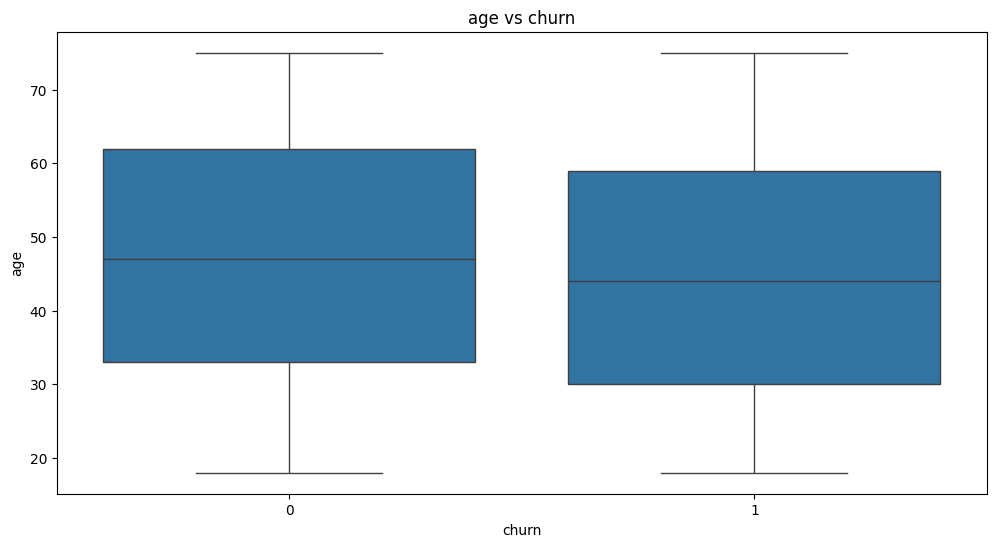

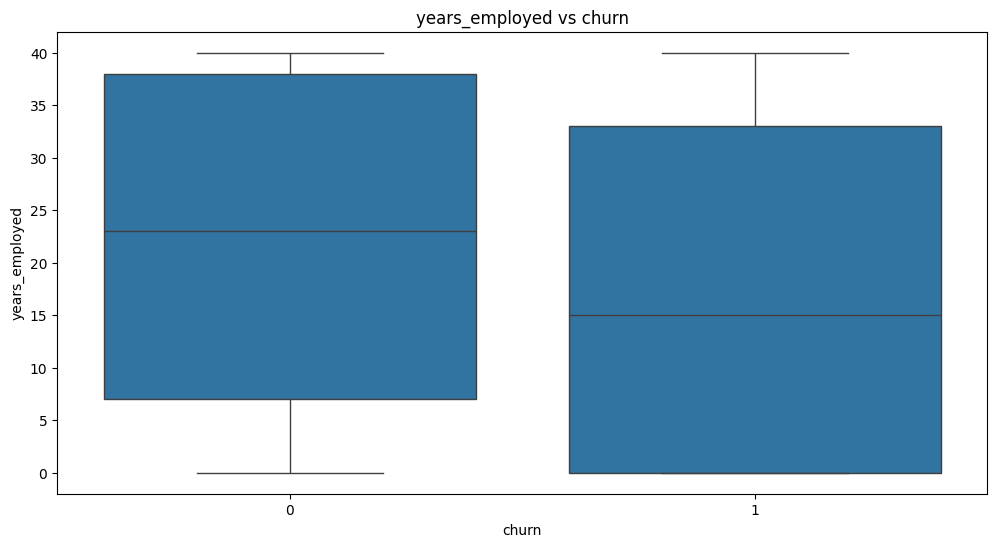

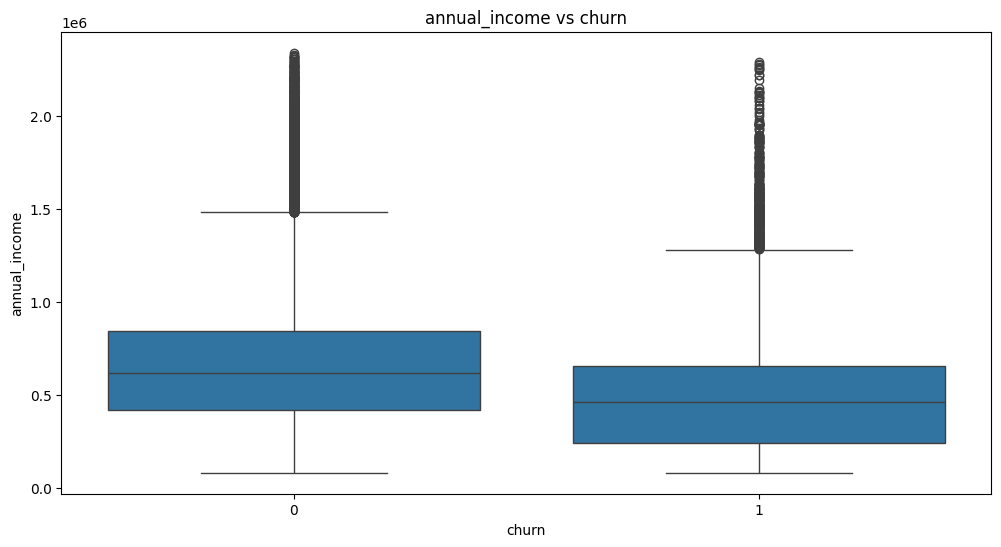

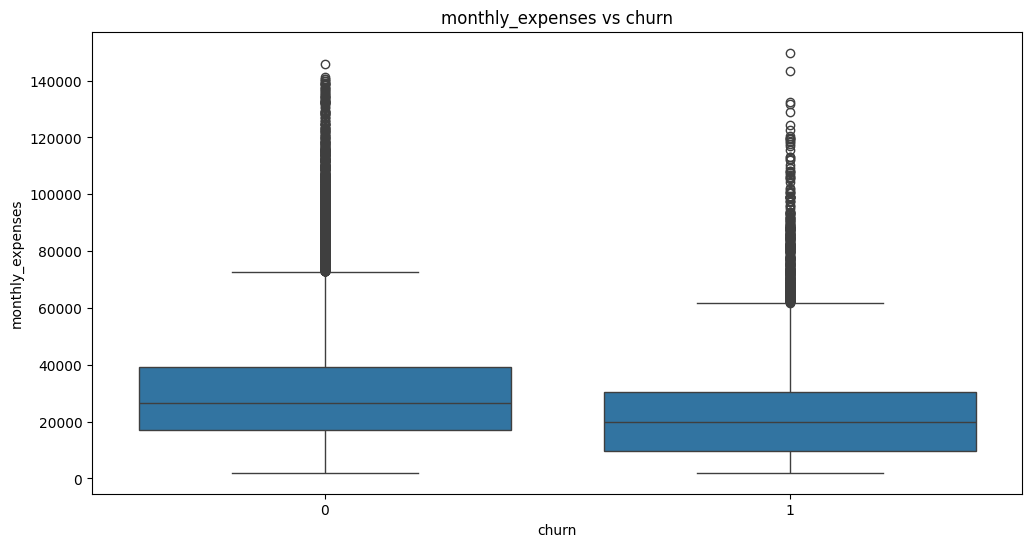

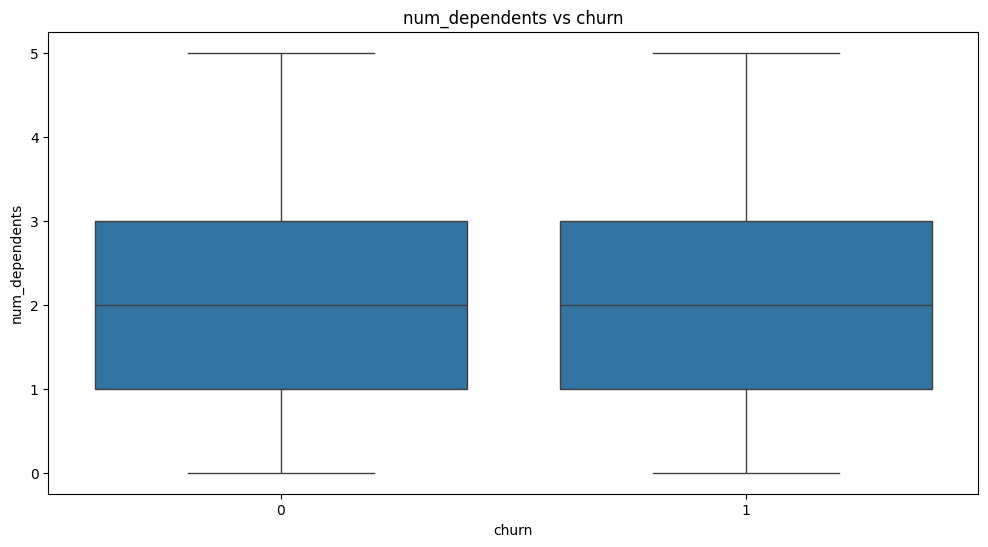

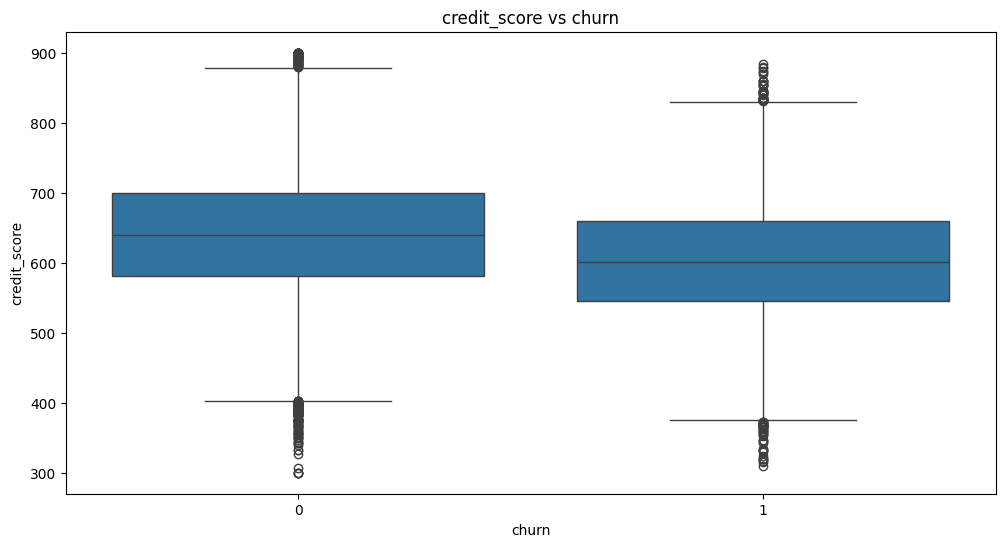

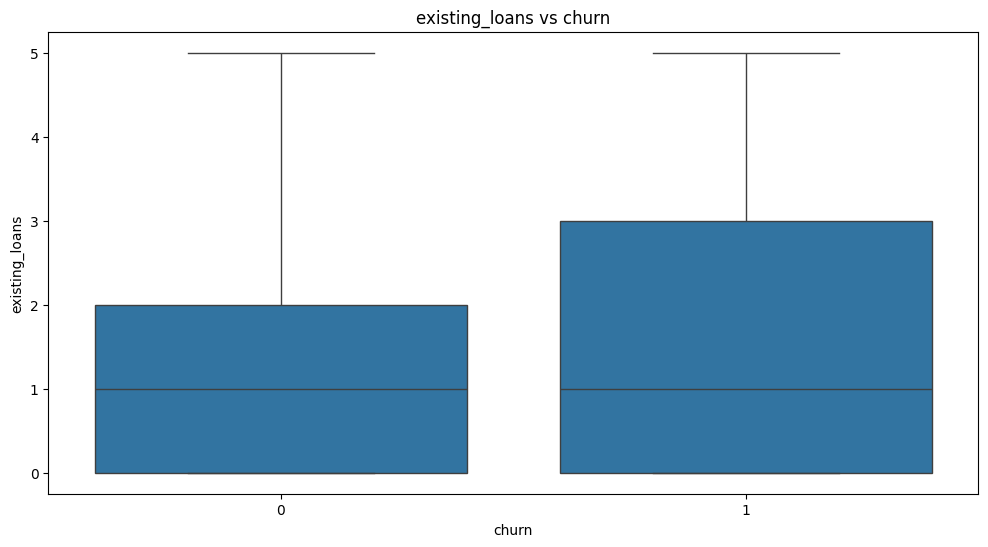

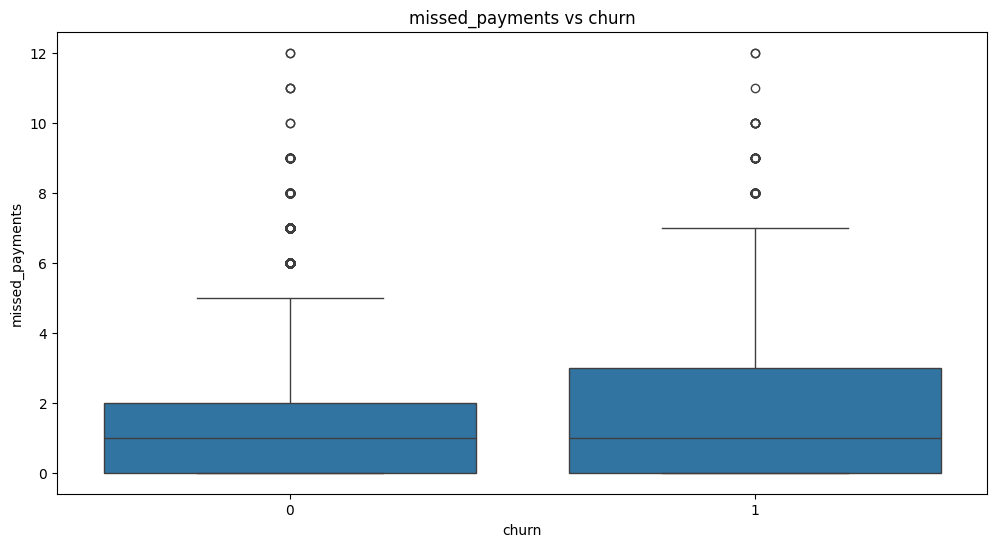

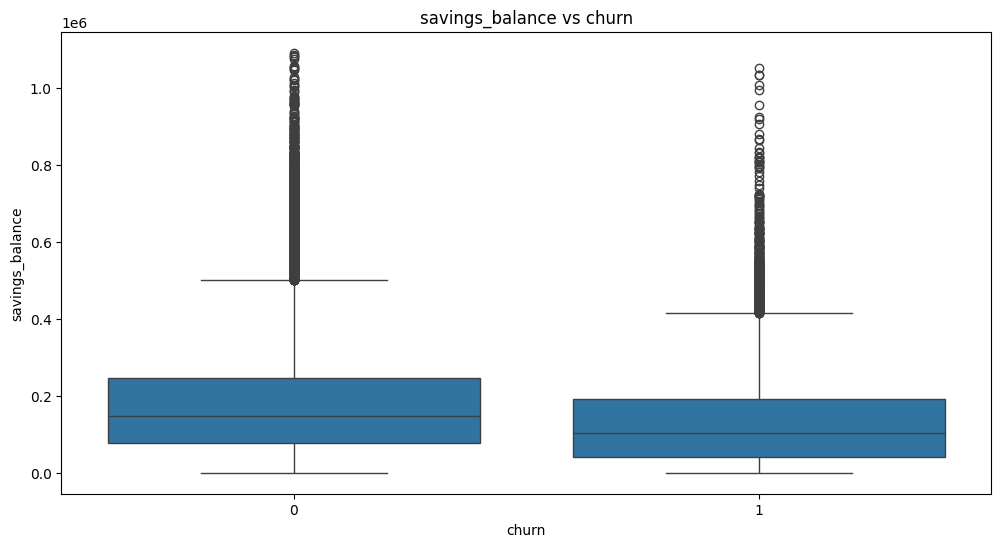

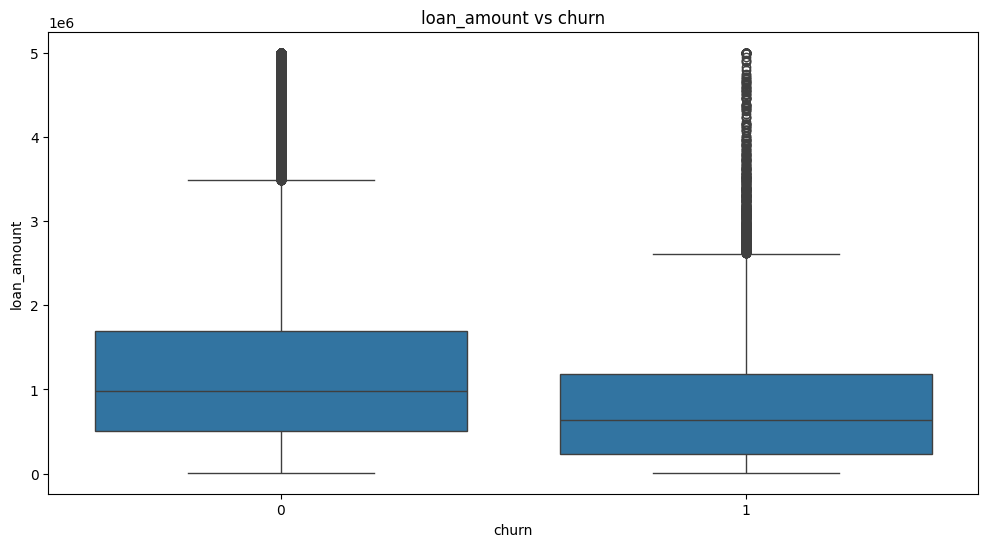

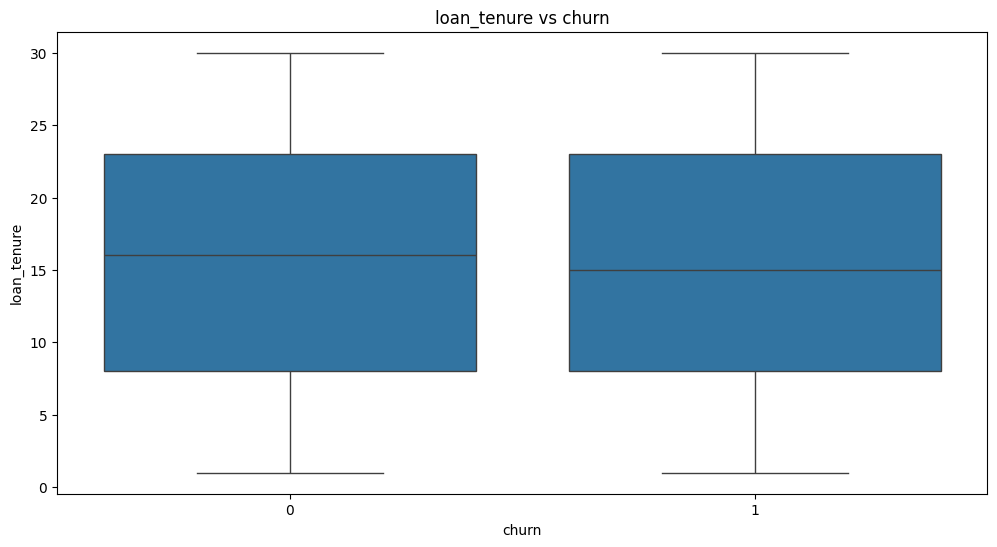

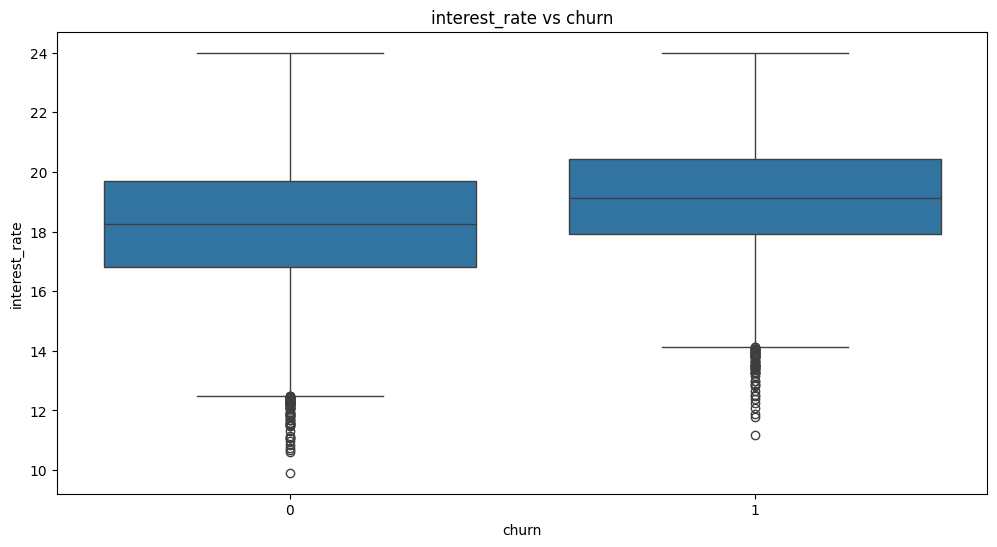

In [27]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns.to_list()
numeric_cols
for col in numeric_cols:
    if col not in ['churn','investment_flag','default']:
        plt.figure(figsize=(12,6))
        sns.boxplot(x='churn',y=col,data=df)
        plt.title(f"{col} vs churn")
        plt.show()
    

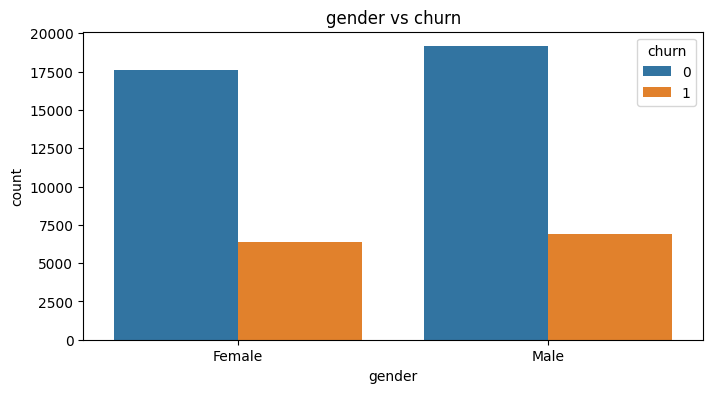

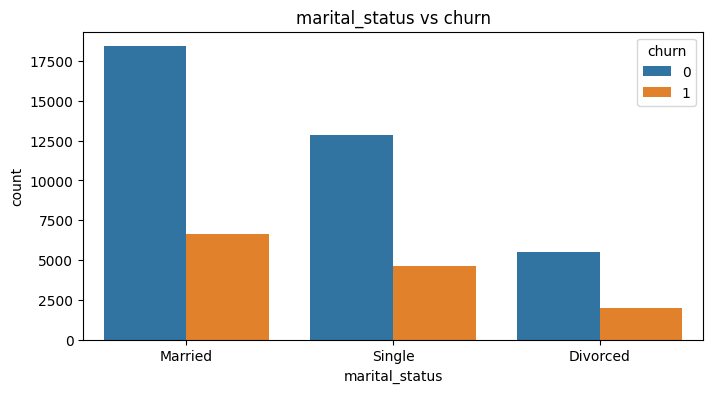

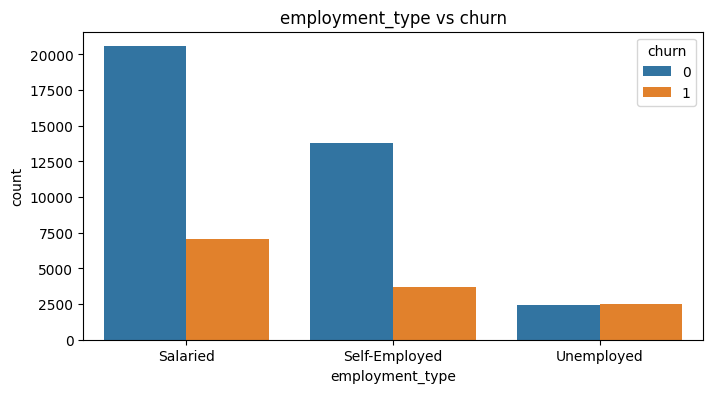

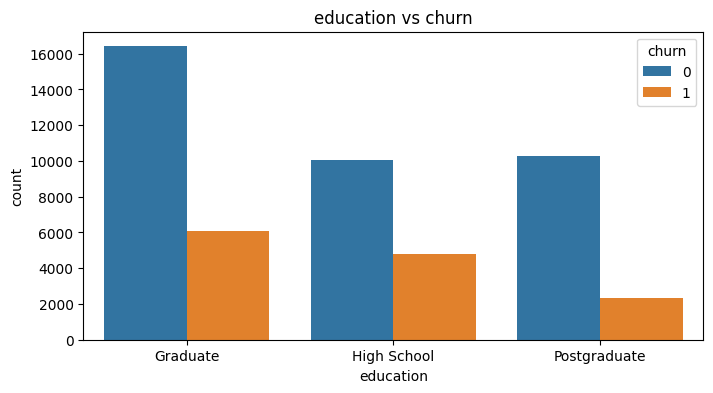

In [35]:
categorical=['gender','marital_status','employment_type','education']
for col in categorical:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,hue='churn',data=df)
    plt.title(f"{col} vs churn")
    plt.show()

In [37]:
for col in categorical:
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    print(f"\n{col} churn rate:")
    print(churn_rate)


gender churn rate:
gender
Female    0.265888
Male      0.264605
Name: churn, dtype: float64

marital_status churn rate:
marital_status
Single      0.266079
Married     0.265297
Divorced    0.262946
Name: churn, dtype: float64

employment_type churn rate:
employment_type
Unemployed       0.511458
Salaried         0.254692
Self-Employed    0.212352
Name: churn, dtype: float64

education churn rate:
education
High School     0.323315
Graduate        0.271258
Postgraduate    0.186249
Name: churn, dtype: float64
